In [2]:
import os
os.chdir(r"C:/Users/OLA/Desktop/MACHINE LEARNING/unsupervisd learning k-clustering/cus_data")
os.getcwd()

'C:\\Users\\OLA\\Desktop\\MACHINE LEARNING\\unsupervisd learning k-clustering\\cus_data'

In [ ]:
%%writefile .gitignore
.ipynb_checkpoints/

In [ ]:
!git init

In [ ]:
!git remote add origin https://github.com/Toyin-dev/customer_data.git

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("Cust_Spend_Data.csv")

In [4]:
df.head(10)

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3
5,6,F,4000,3,0,1,8
6,7,G,2500,5,0,11,2
7,8,H,2500,3,0,1,1
8,9,I,2000,2,0,2,2
9,10,J,1000,4,0,1,7


In [5]:
df.shape

(10, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Cust_ID          10 non-null     int64 
 1   Name             10 non-null     object
 2   Avg_Mthly_Spend  10 non-null     int64 
 3   No_Of_Visits     10 non-null     int64 
 4   Apparel_Items    10 non-null     int64 
 5   FnV_Items        10 non-null     int64 
 6   Staples_Items    10 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 692.0+ bytes


In [7]:
df.columns

Index(['Cust_ID', 'Name', 'Avg_Mthly_Spend', 'No_Of_Visits', 'Apparel_Items',
       'FnV_Items', 'Staples_Items'],
      dtype='object')

In [8]:
df.dtypes

Cust_ID             int64
Name               object
Avg_Mthly_Spend     int64
No_Of_Visits        int64
Apparel_Items       int64
FnV_Items           int64
Staples_Items       int64
dtype: object

In [9]:
df.isnull().sum()

Cust_ID            0
Name               0
Avg_Mthly_Spend    0
No_Of_Visits       0
Apparel_Items      0
FnV_Items          0
Staples_Items      0
dtype: int64

In [10]:
data2 = df.iloc[:, 2:]
data2

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,10000,2,1,1,0
1,7000,3,0,10,9
2,7000,7,1,3,4
3,6500,5,1,1,4
4,6000,6,0,12,3
5,4000,3,0,1,8
6,2500,5,0,11,2
7,2500,3,0,1,1
8,2000,2,0,2,2
9,1000,4,0,1,7


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x800 with 0 Axes>

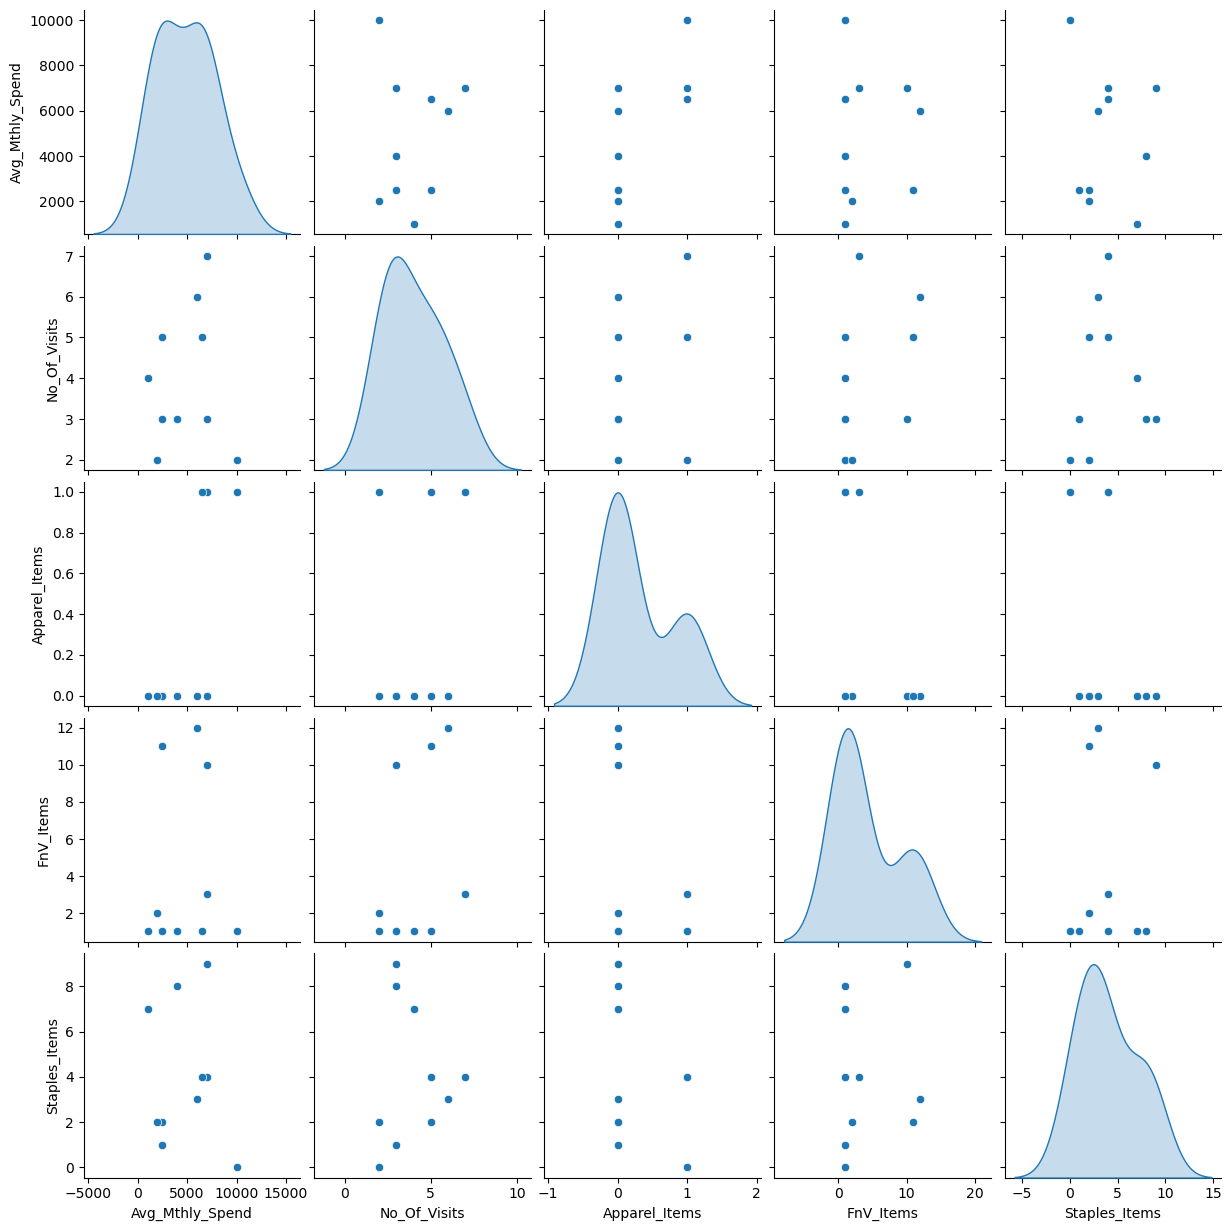

In [11]:
plt.figure(figsize = (10, 8))
sns.pairplot(data2, diag_kind = 'kde')
plt.show()

In [12]:
from scipy.stats import zscore
data3 = data2.apply(zscore)
data3

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1.886498,-1.240347,1.527525,-0.741433,-1.380131
1,0.787567,-0.620174,-0.654654,1.280656,1.725164
2,0.787567,1.860521,1.527525,-0.292080,0.000000
3,0.604412,0.620174,1.527525,-0.741433,0.000000
4,0.421257,1.240347,-0.654654,1.730009,-0.345033
5,-0.311364,-0.620174,-0.654654,-0.741433,1.380131
6,-0.860829,0.620174,-0.654654,1.505333,-0.690066
7,-0.860829,-0.620174,-0.654654,-0.741433,-1.035098
8,-1.043984,-1.240347,-0.654654,-0.516756,-0.690066
9,-1.410294,0.000000,-0.654654,-0.741433,1.035098


In [13]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'average')
model.fit(data3)

AgglomerativeClustering(linkage='average', metric='euclidean', n_clusters=3)

In [14]:
df['labels'] = model.labels_
df

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
0,1,A,10000,2,1,1,0,0
1,2,B,7000,3,0,10,9,1
2,3,C,7000,7,1,3,4,0
3,4,D,6500,5,1,1,4,0
4,5,E,6000,6,0,12,3,1
5,6,F,4000,3,0,1,8,2
6,7,G,2500,5,0,11,2,1
7,8,H,2500,3,0,1,1,2
8,9,I,2000,2,0,2,2,2
9,10,J,1000,4,0,1,7,2


In [15]:
df[df['labels'] == 0]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
0,1,A,10000,2,1,1,0,0
2,3,C,7000,7,1,3,4,0
3,4,D,6500,5,1,1,4,0


In [16]:
df[df['labels'] == 1]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
1,2,B,7000,3,0,10,9,1
4,5,E,6000,6,0,12,3,1
6,7,G,2500,5,0,11,2,1


In [17]:
df[df['labels'] == 2]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
5,6,F,4000,3,0,1,8,2
7,8,H,2500,3,0,1,1,2
8,9,I,2000,2,0,2,2,2
9,10,J,1000,4,0,1,7,2


In [18]:
data2['labels'] = model.labels_

In [19]:
data_clust = data2.groupby(['labels'])
data_clust.mean()

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
labels,,,,,
0,7833.333333,4.666667,1.0,1.666667,2.666667
1,5166.666667,4.666667,0.0,11.000000,4.666667
2,2375.000000,3.000000,0.0,1.250000,4.500000


## Cophenetic Correlation

In [20]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

In [21]:
z = linkage(data3, metric = 'euclidean', method = 'average')
c, cophen = cophenet(z, pdist(data3))
c

0.8681149436293064

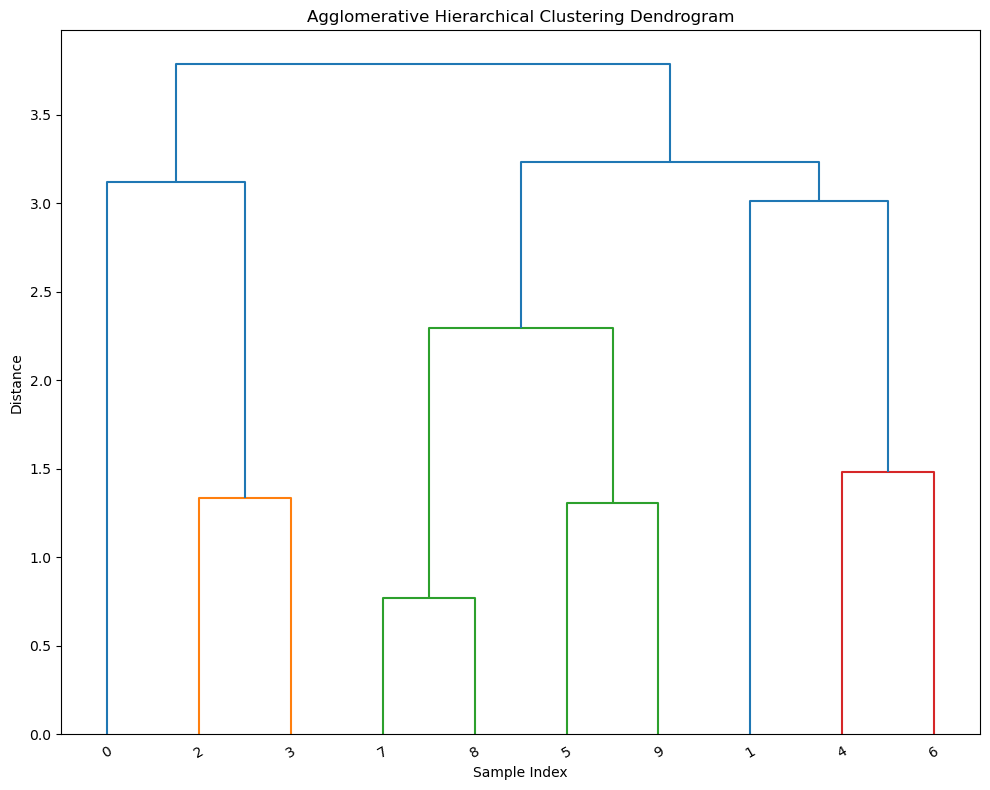

In [22]:
plt.figure(figsize = (10, 8))
plt.title("Agglomerative Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

dendrogram(z, leaf_rotation = 30, leaf_font_size = 10)
plt.tight_layout()

In [23]:
z = linkage(data3, metric = 'euclidean', method = 'complete')
c, cophen = cophenet(z, pdist(data3))
c

0.8606955190809153

In [24]:
z = linkage(data3, metric = 'euclidean', method = 'ward')
c, cophen = cophenet(z, pdist(data3))
c

0.8453818941339526